In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path().resolve().parent
sys.path.insert(0, str(REPO_ROOT))

from analysis import *
from analysis.aggregations import *
from analysis.plots import *

## Jupyter notes

## A single run

In [2]:
#FOLDER = "04-03-26--14_34_00/mnist-accuracy_only-3-1.0-3-1.0-True-False.pkl"

# FOLDER = "26-02-26--11_04_41/mnist-accuracy_only-3-1.0-3-1.0-True-False.pkl"

# FOLDER = "05-03-26--14_56_45/mnist-accuracy_only-3-1.0-3-1.0-True-False.pkl"

FOLDER = "12-03-26--13_50_41/mnist-accuracy_only-1-1.0-1-1.0-True-True.pkl"


data_dir = REPO_ROOT / "experiment" / "data" / "experimentData"
if FOLDER:
    data_dir = data_dir / FOLDER

run = load_run(data_dir)

# Normalize units: wei → ETH, ratio → %
run = normalize_run(run)
res = merge_runs([run])

### Aggregate global accuracy by round

In [3]:
# data = res['users']
# aggregated = agg_global_accuracy_by_round(data)
#
# aggregated

## Multiple runs

In [4]:
# FOLDER = "26-02-26--11_04_41/"
#
# data_dir = REPO_ROOT / "experiment" / "data" / "experimentData"
# if FOLDER:
#     data_dir = data_dir / FOLDER
#
# runs = load_runs(data_dir)
#
# # Normalize units: wei → ETH, ratio → %
# runs = normalize_runs(runs)
# res = merge_runs(runs)

## Plots

## Plot: GRS by user

In [5]:
data = res['users']

# data[['grs', 'user_id', 'round']]

vals = grs_by_user(data)

# fig = plot_grs_by_user(vals)

# data[vals['user_id'].isin([4, 5])].sort_values(['user_id', 'round'])

c = res['contributions']
# data[vals['round']>1]
# run.setup
u = res['users']
v = res['votes']

# v[['experiment_id', 'round', 'receiver_id', 'votes_accuracy']]
# c[['experiment_id', 'round', 'user_id', 'current_excluded_values', 'current_mad_median', 'current_mad_value', 'current_mad_max_deviation']]


# vote_res = v[['experiment_id', 'round', 'receiver_id', 'votes_accuracy']]
# contrib_res = c[['experiment_id', 'round', 'user_id', 'current_accepted_values', 'current_excluded_values', 'current_mad_median', 'current_mad_value', 'current_mad_max_deviation']]
#
# merged = vote_res.merge(contrib_res, left_on=['experiment_id', 'round', 'receiver_id'], right_on=['experiment_id', 'round', 'user_id'], how='inner').drop(columns='user_id').rename(columns={'receiver_id': 'user_id'})
#
# # be careful with float comparison - hense we use np.isClose
# merged['is_outlier'] = merged.apply(
#   lambda row: any(np.isclose(row['votes_accuracy'], v) for v in row['current_excluded_values']),
#   axis=1
# )



# Step 4 — then you can push is_outlier back into c for the transform merge
# c = c.merge(
#   merged[['experiment_id', 'round', 'user_id', 'is_outlier']]
#   .rename(columns={'receiver_id': 'user_id'}),  # already dropped user_id above
#   on=['experiment_id', 'round', 'user_id'],
#   how='left'
# )

v
## Convert receiver_id and user_id -> user_id, place where receiver_id is.
## Logic to determine if votes_accuracy is in current_excluded values -> is_outlier {true, false}


,round,user_id,votes_accuracy,current_accepted_values,current_excluded_values,current_mad_median,current_mad_value,current_mad_max_deviation,is_outlier,experiment_id
0,1,1,6940,"[6940.0, 7050.0, 6890.0]","[0.0, 610.0]",6890.0,160.0,260.934025,False,mnist-accuracy_only-1-1.0-1-1.0-True-True
1,1,2,6790,"[6790.0, 6660.0, 6580.0]","[0.0, 610.0]",6580.0,210.0,342.475908,False,mnist-accuracy_only-1-1.0-1-1.0-True-True
2,1,3,6060,"[6060.0, 5850.0, 5930.0]","[0.0, 610.0]",5850.0,210.0,342.475908,False,mnist-accuracy_only-1-1.0-1-1.0-True-True
3,1,4,670,"[670.0, 720.0, 740.0, 610.0]",[570.0],670.0,60.0,97.850259,False,mnist-accuracy_only-1-1.0-1-1.0-True-True
4,1,5,580,"[580.0, 720.0, 840.0, 690.0]",[0.0],690.0,110.0,179.392142,False,mnist-accuracy_only-1-1.0-1-1.0-True-True
5,1,0,7660,"[7660.0, 7690.0, 7330.0]","[0.0, 610.0]",7330.0,360.0,587.101557,False,mnist-accuracy_only-1-1.0-1-1.0-True-True
6,1,2,6660,"[6790.0, 6660.0, 6580.0]","[0.0, 610.0]",6580.0,210.0,342.475908,False,mnist-accuracy_only-1-1.0-1-1.0-True-True
7,1,3,5850,"[6060.0, 5850.0, 5930.0]","[0.0, 610.0]",5850.0,210.0,342.475908,False,mnist-accuracy_only-1-1.0-1-1.0-True-True
8,1,4,720,"[670.0, 720.0, 740.0, 610.0]",[570.0],670.0,60.0,97.850259,False,mnist-accuracy_only-1-1.0-1-1.0-True-True
9,1,5,720,"[580.0, 720.0, 840.0, 690.0]",[0.0],690.0,110.0,179.392142,False,mnist-accuracy_only-1-1.0-1-1.0-True-True


## Plot: Model Performance by Global Accuracy for aggregation strategies

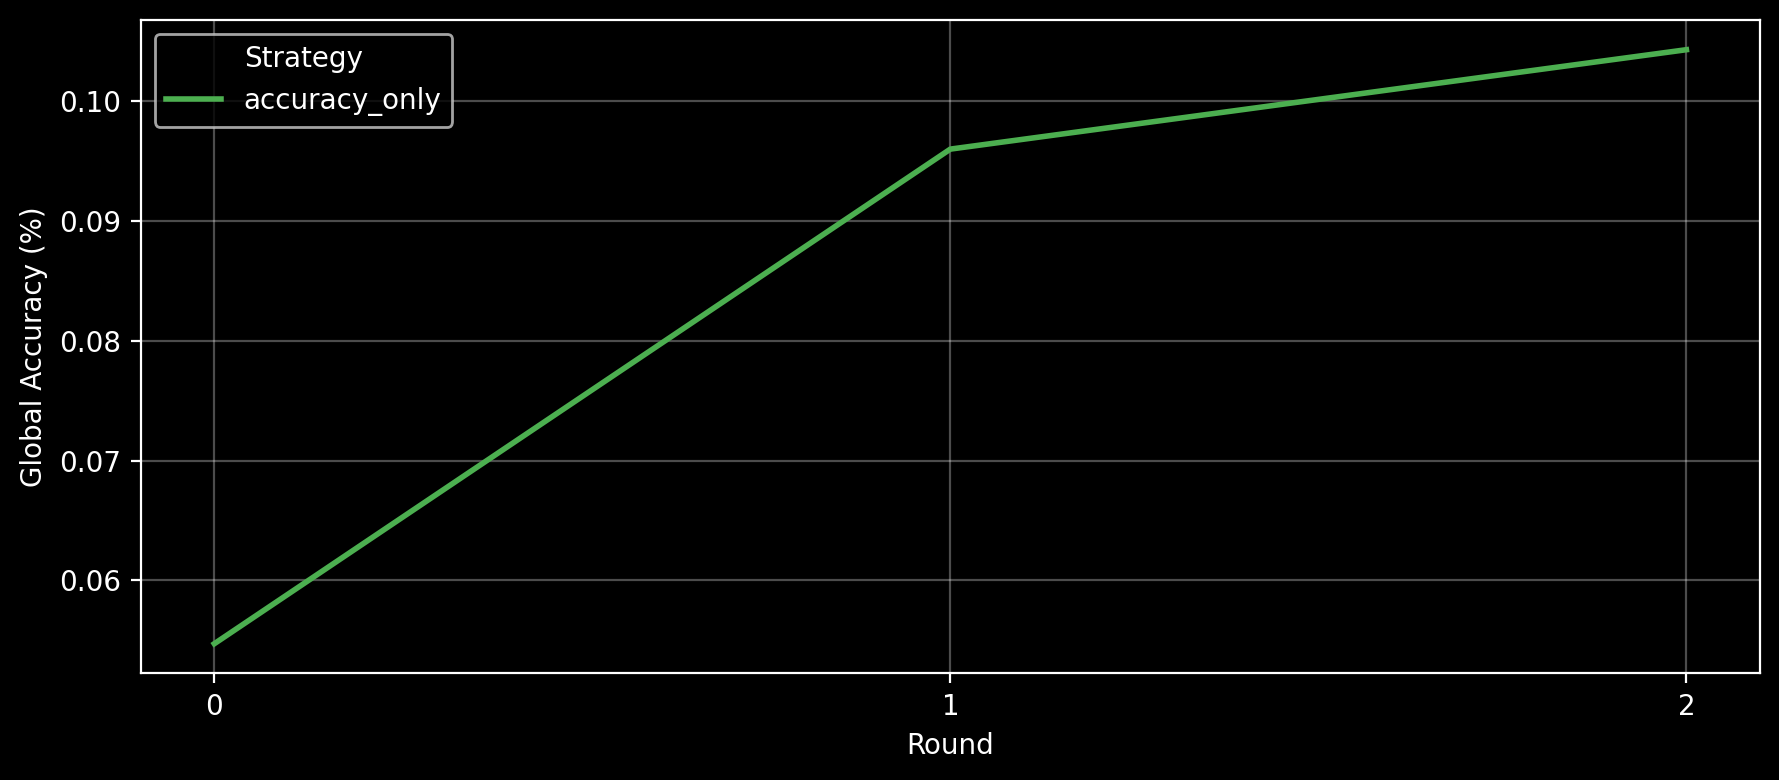

In [6]:
data = res['global']

# It logs self.pytorch_model.accuracy[-1] — so it's the accuracy of the global model evaluated after
# merging all participants' weights each round. That's the true global model performance, distinct from
# individual user accuracies.

# vals = grs_by_user(data)
# data[['round', 'global_accuracy']]
# data[vals['user_id'].isin([4, 5])].sort_values(['user_id', 'round'])

# data

vals = global_acc_by_aggregation_strategy(data, res['metadata'])


fig = plot_global_acc_by_aggregation_strategy(vals)

## Plot: Model Performance by Global Loss for aggregation strategies

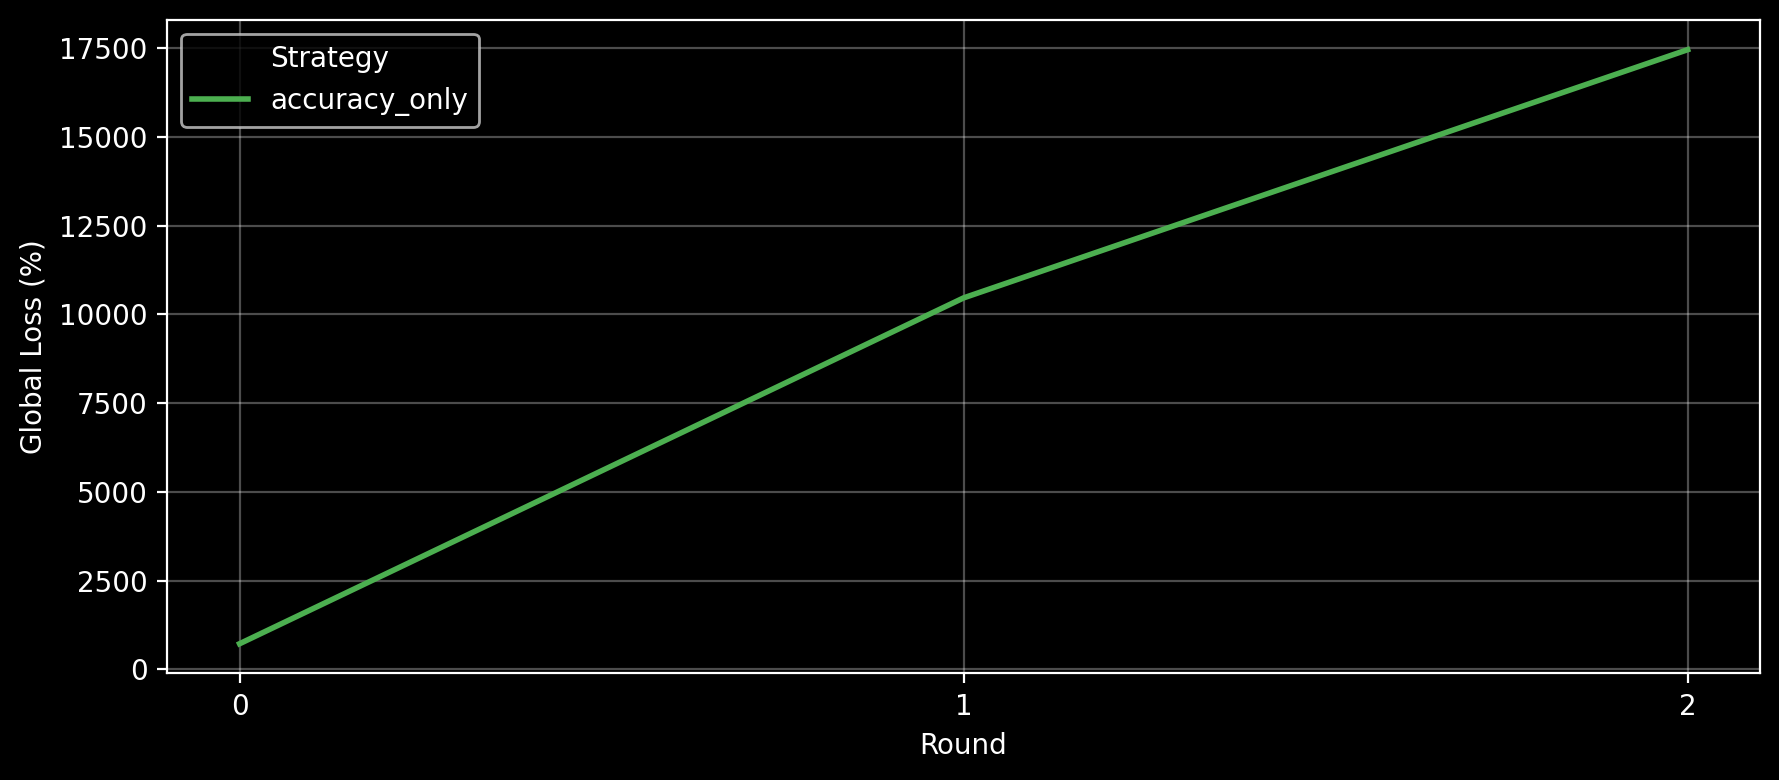

In [7]:
data = res['global']

# ●It logs self.pytorch_model.loss[-1] — so it's the loss of the global model evaluated after
#  merging all participants' weights each round. That's the true global model performance, distinct from
#  individual user accuracies.

# vals = grs_by_user(data)
# data[['round', 'global_loss']]
# data[vals['user_id'].isin([4, 5])].sort_values(['user_id', 'round'])

# data

vals = global_loss_by_aggregation_strategy(data, res['metadata'])
fig = plot_global_loss_by_aggregation_strategy(vals)

## Query: Runtime warnings

In [8]:
# data = res['setup'] does not work

data = res['warnings']
